# Kịch bản 3 — Multi-station input → BenLuc
**Input:** Salinity_BenLuc + Salinity_CauNoi + Salinity_TanAn + wind_speed + temp + total_precipitation  
**Target:** Salinity_BenLuc  
**Models:** RNN, LSTM, GRU, CNN-LSTM  
**Lookback × Horizon:** {12, 24, 48}h × {12, 24, 48}h = 9 tổ hợp  
**Tổng:** 4 × 9 = **36 thí nghiệm**


In [4]:
import sys, os
import itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from models import build_model
from patchTST_Base import PatchTST_BASE
from patchTST_Attention import PatchTST_ATTENTION
from patchTST_V2 import PatchTST_V2
from patchTST_Cross import PatchTST_CROSS
from patchTST_CT import CT_PatchTST
from patchTST_CT_v2 import CT_PatchTST_Joint
from patchTST_CT_LSTM import CT_PatchTST_LSTM
from patchTST_Parallel import CT_PatchTST_Parallel
from GAT_patchTST import GAT_PatchTST
import joblib
warnings.filterwarnings("ignore")

import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/final_dataset")
OUTPUT_DIR = Path("outputs")
PLOT_DIR   = OUTPUT_DIR / "plots"
MODEL_DIR  = OUTPUT_DIR / "models"
for d in [PLOT_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

# ── Splits ─────────────────────────────────────────────────────────────
TRAIN_YEARS = [2020, 2021, 2022]
VAL_YEARS   = [2023]
TEST_YEARS  = [2025]

STATIONS     = ["BenLuc", "CauNoi", "TanAn"]
FEATURE_COLS = ["wind_speed", "temp", "total_precipitation"]
#"PATCHTST_BASE","CT_PATCHTST",
MODEL_NAMES  = ["PATCHTST_BASE"]
LOOKBACKS    = [168]   # bước × 2h → 12h, 24h, 48h
HORIZONS     = [24]

# ── Hyperparameters ────────────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 1e-3
PATIENCE   = 15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [6]:
def load_station(name: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"{name}_clean.csv",
                       parse_dates=["Time"])

def split_years(df: pd.DataFrame, years: list) -> pd.DataFrame:
    return df[df["Time"].dt.year.isin(years)].copy()

def load_split(stations: list, target: str):
    """Load & split all needed station data."""
    data = {s: load_station(s) for s in set(stations + [target])}
    splits = {}
    for label, yrs in [("train", TRAIN_YEARS), ("val", VAL_YEARS), ("test", TEST_YEARS)]:
        splits[label] = {s: split_years(data[s], yrs) for s in data}
    return splits


In [7]:
class SalinityDataset(Dataset):
    def __init__(self, X, y, F):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.F = torch.tensor(F, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i], self.F[i]

def make_windows(features, target, lookback, horizon):
    Xs, ys, Fs = [], [], []
    for i in range(len(features) - lookback - horizon + 1):
        Xs.append(features[i:i+lookback])
        ys.append(target[i+lookback:i+lookback+horizon])
        Fs.append(features[i+lookback:i+lookback+horizon, -6:])  # tương lai đã biết
    if not Xs:
        return (np.empty((0, lookback, features.shape[1]), np.float32),
                np.empty((0, horizon), np.float32),
                np.empty((0, horizon, 6), np.float32))
    return np.array(Xs, np.float32), np.array(ys, np.float32), np.array(Fs, np.float32)
def make_windows_gapaware(df, X_sc, y_sc, lookback, horizon, step=pd.Timedelta("2h")):
    seg_id = (df["Time"].diff() != step).cumsum()
    Xa, ya, Fa = [], [], []
    for _, idx in df.groupby(seg_id).indices.items():
        Xw, yw, Fw = make_windows(X_sc[idx], y_sc[idx], lookback, horizon)
        if len(Xw): Xa.append(Xw); ya.append(yw); Fa.append(Fw)
    if not Xa:   # không có đoạn nào đủ dài → trả mảng rỗng đúng shape
        return (np.empty((0, lookback, X_sc.shape[1]), dtype=np.float32),
                np.empty((0, horizon), dtype=np.float32))
    return np.concatenate(Xa), np.concatenate(ya), np.concatenate(Fa)
def add_tide_features(df, time_col="Time"):
    df_feat = df.copy()
    df_feat[time_col] = pd.to_datetime(df_feat[time_col])

    hours = df_feat[time_col].dt.hour + df_feat[time_col].dt.minute / 60.0

    df_feat['hour_sin'] = np.sin(2*np.pi*hours/24.0)
    df_feat['hour_cos'] = np.cos(2*np.pi*hours/24.0)

    reference_new_moon = pd.to_datetime("2020-01-25 04:42:00")

    delta_day = (df_feat[time_col] - reference_new_moon).dt.total_seconds()/(24*3600)

    lunar_cycle = 29.530588
    lunar_phase = delta_day%lunar_cycle

    df_feat['lunar_sin'] = np.sin(2 * np.pi * lunar_phase / lunar_cycle)
    df_feat['lunar_cos'] = np.cos(2* np.pi * lunar_phase / lunar_cycle)

    day_of_year = df_feat[time_col].dt.dayofyear
    day_in_year = 365.2425
    df_feat['year_sin'] = np.sin(2 * np.pi * day_of_year/day_in_year)
    df_feat['year_cos'] = np.cos(2 * np.pi * day_of_year/day_in_year)

    return df_feat
def build_dataset(splits, input_stations, target_station,
                  lookback, horizon, scaler_X=None, scaler_y=None, fit=False):
    """
    Merge input features, build sliding windows per split.
    Returns X_arr, y_arr, scaler_X, scaler_y
    """
    sal_cols    = [f"Salinity_{s}" for s in input_stations]
    target_col  = f"Salinity_{target_station}"
    feature_cols = sal_cols + FEATURE_COLS + ['hour_sin', 'hour_cos', 'lunar_sin', 'lunar_cos', 'year_sin', 'year_cos']

    all_X, all_y = [], []
    for split_name in ["train", "val", "test"] if fit else []:
        pass  # handled below

    def _merge_split(split_dfs):
        dfs = [split_dfs[s][["Time", f"Salinity_{s}"]].copy() for s in input_stations]
        merged = dfs[0]
        for d in dfs[1:]:
            merged = pd.merge(merged, d, on="Time", how="inner")
        meteo = split_dfs[input_stations[0]][["Time"] + FEATURE_COLS]
        merged = pd.merge(merged, meteo, on="Time", how="inner")
        if target_col not in merged.columns:
            tgt = split_dfs[target_station][["Time", target_col]]
            merged = pd.merge(merged, tgt, on="Time", how="inner")
        merged = merged.sort_values("Time").reset_index(drop=True)
        
        merged = add_tide_features(merged)
        
        return merged

    # Fit scalers on train
    train_merged = _merge_split(splits["train"])
    X_raw = train_merged[feature_cols].values.astype(np.float32)
    y_raw = train_merged[[target_col]].values.astype(np.float32)
    if fit:
        scaler_X = StandardScaler(); scaler_X.fit(X_raw)
        scaler_y = StandardScaler(); scaler_y.fit(y_raw)

    result = {}
    for split_name, split_dfs in splits.items():
        merged = _merge_split(split_dfs)
        X_sc = scaler_X.transform(merged[feature_cols].values.astype(np.float32))
        y_sc = scaler_y.transform(merged[[target_col]].values.astype(np.float32)).flatten()
        Xa, ya, Fa = [], [], []
        for yr in sorted(merged["Time"].dt.year.unique()):
            m = merged["Time"].dt.year == yr
            Xw, yw, Fw = make_windows(X_sc[m], y_sc[m], lookback, horizon)
            Xa.append(Xw); ya.append(yw), Fa.append(Fw)
        result[split_name] = (np.concatenate(Xa), np.concatenate(ya), np.concatenate(Fa))

    return result, scaler_X, scaler_y


In [8]:
def train_model(model, tr_loader, val_loader,lr=LR):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val, pat_cnt, best_state = float("inf"), 0, None
    history = {"train": [], "val": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss = 0.0
        for Xb, yb, Fb in tr_loader:
            Xb, yb, Fb = Xb.to(DEVICE), yb.to(DEVICE), Fb.to(DEVICE)
            opt.zero_grad()
            out = model(Xb, Fb) if getattr(model, "use_future", False) else model(Xb)
            loss = criterion(out, yb)
            if getattr(model, "aux_loss", None) is not None:
                loss = loss + model.aux_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(Xb)
        tr_loss /= len(tr_loader.dataset)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb, Fb in val_loader:
                Xb, yb, Fb = Xb.to(DEVICE), yb.to(DEVICE), Fb.to(DEVICE)
                out = model(Xb, Fb) if getattr(model, "use_future", False) else model(Xb)
                vl_loss += criterion(out, yb).item() * len(Xb)
        vl_loss /= len(val_loader.dataset)

        history["train"].append(tr_loss)
        history["val"].append(vl_loss)
        sch.step(vl_loss)

        if vl_loss < best_val:
            best_val  = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt   = 0
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, history

def evaluate(model, loader, scaler_y):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb, Fb in loader:                                   # SỬA 1: thêm Fb
            Xb, Fb = Xb.to(DEVICE), Fb.to(DEVICE)                   # SỬA 2
            out = model(Xb, Fb) if getattr(model, "use_future", False) else model(Xb)   # SỬA 3
            preds.append(out.cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    pi = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
    ti = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(trues.shape)
    flat_p, flat_t = pi.flatten(), ti.flatten()
    return {
        "rmse": float(np.sqrt(mean_squared_error(flat_t, flat_p))),
        "mae" : float(mean_absolute_error(flat_t, flat_p)),
        "r2"  : float(r2_score(flat_t, flat_p)),
        "preds": pi, "trues": ti,
    }


In [9]:
def plot_loss(history, tag):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(history["train"], label="Train")
    ax.plot(history["val"],   label="Validation")
    ax.set_title(f"Loss — {tag}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); fig.tight_layout()
    fig.savefig(PLOT_DIR / f"loss_{tag}.png", dpi=110)
    plt.close(fig)

def plot_pred(preds, trues, tag):
    """
    2 subplot:
      - Trên: trung bình ngày toàn bộ test set → thấy xu hướng xâm nhập mặn
      - Dưới: chi tiết 7 ngày đầu theo từng bước 2h → thấy dao động thủy triều
    preds/trues shape: (N_samples, horizon)
    """
    # Lấy bước cuối của mỗi window → chuỗi dự báo liên tục
    p = preds[:, -1]   # (N,)
    t = trues[:, -1]   # (N,)
    n = len(p)

    # ── Panel trên: trung bình theo ngày ─────────────────────────
    # Mỗi bước = 2h → 12 bước/ngày
    steps_per_day = 12
    n_days = n // steps_per_day
    p_daily = p[:n_days*steps_per_day].reshape(n_days, steps_per_day).mean(axis=1)
    t_daily = t[:n_days*steps_per_day].reshape(n_days, steps_per_day).mean(axis=1)

    # ── Panel dưới: 7 ngày đầu (84 bước) ─────────────────────────
    n_detail = min(84, n)   # 7 ngày × 12 bước/ngày

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
                                   gridspec_kw={"height_ratios": [1.2, 1]})
    fig.suptitle(tag, fontsize=10, color="#424242")

    # Panel 1 — xu hướng theo ngày
    ax1.plot(t_daily, label="Thực tế",  lw=1.4, color="#1565C0")
    ax1.plot(p_daily, label="Dự báo",   lw=1.2, color="#E53935", alpha=0.85)
    ax1.set_title("Xu hướng toàn tập Test (trung bình ngày)", fontsize=10)
    ax1.set_xlabel("Ngày"); ax1.set_ylabel("Độ mặn TB (g/l)")
    ax1.spines[["top","right"]].set_visible(False)
    ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
    ax1.set_axisbelow(True)
    ax1.legend(fontsize=9)

    # Panel 2 — chi tiết 7 ngày
    xticks = list(range(0, n_detail, steps_per_day))
    xlabels = [f"Ngày {i//steps_per_day+1}" for i in xticks]
    ax2.plot(t[:n_detail], label="Thực tế",  lw=1.2, color="#1565C0")
    ax2.plot(p[:n_detail], label="Dự báo",   lw=1.0, color="#E53935", alpha=0.85)
    ax2.set_title("Chi tiết 7 ngày đầu (bước 2h — thấy dao động thủy triều)", fontsize=10)
    ax2.set_xlabel("Thời gian"); ax2.set_ylabel("Độ mặn (g/l)")
    ax2.set_xticks(xticks); ax2.set_xticklabels(xlabels, fontsize=8)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
    ax2.set_axisbelow(True)
    ax2.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"pred_{tag}.png", dpi=110, bbox_inches="tight")
    plt.close(fig)

In [19]:
import json
with open(r"C:\Users\Qminh\Desktop\Paper2026\SaltIntrusion\src_code\outputs\gridsearch\plots\best_params_2.json") as f:
    BEST_PARAMS = json.load(f)

#Thêm tham số cho mô hình mới (chỉnh tay các con số ở đây)
BEST_PARAMS["PATCHTST_BASE"] = {
        "hidden_size":   128,     # d_model
        "num_layers":    3,
        "learning_rate": 1e-4,    # KHÔNG dùng 1e-3 — dễ phân kỳ
        "batch_size":    32,
        "patch_len":     2,       # 12h ~ 1 con nước
        "stride":        12,
    }
BEST_PARAMS["PATCHTST_ATTENTION"] = {
        "hidden_size":   128,     # d_model
        "num_layers":    3,
        "learning_rate": 1e-4,    # KHÔNG dùng 1e-3 — dễ phân kỳ
        "batch_size":    32,
        "patch_len":     6,       # 12h ~ 1 con nước
        "stride":        6,
    }
BEST_PARAMS["PATCHTST_V2"] = {
        "hidden_size":   128,     # d_model
        "num_layers":    3,
        "learning_rate": 1e-4,    # KHÔNG dùng 1e-3 — dễ phân kỳ
        "batch_size":    32,
        "patch_len":     6,       # 12h ~ 1 con nước
        "stride":        6,
        "use_future": True,
    }

BEST_PARAMS["PATCHTST_CROSS"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["CT_PATCHTST"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["CT_PATCHTST_V2"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["CT_PATCHTST_LSTM"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["CT_PATCHTST_LSTM"].update({
    "n_joint_layers": 1,        # Số lớp Joint Attention
    "lstm_hidden_size": 256,    # Số node ẩn của LSTM
    "lstm_layers": 2            # Số tầng LSTM
})
BEST_PARAMS["CT_PATCHTST_PARALLEL"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["CT_PATCHTST_PARALLEL"].update({
    "rnn_type": "LSTM",         # Có thể thay bằng "GRU"
    "rnn_hidden_size": 256,      # Số node của mạng LSTM
    "rnn_layers": 1             # Số tầng LSTM
})
BEST_PARAMS["GAT_PATCHTST"] = dict(BEST_PARAMS["PATCHTST_BASE"])
BEST_PARAMS["GAT_PATCHTST"].update({
    "gat_hidden_dim": 16,     # Độ lớn vector đặc trưng lan truyền giữa các trạm
    "patch_len": 6,           # Chiều dài 1 cụm thời gian (6 bước = 12 giờ)
    "stride": 6,              # Khoảng cách trượt
})
print(BEST_PARAMS)

{'RNN': {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'learning_rate': 0.0001}, 'LSTM': {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'learning_rate': 0.001}, 'GRU': {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'learning_rate': 0.0005}, 'CNN_LSTM': {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'learning_rate': 0.001}, 'PATCHTST_BASE': {'hidden_size': 128, 'num_layers': 3, 'learning_rate': 0.0001, 'batch_size': 32, 'patch_len': 2, 'stride': 12}, 'PATCHTST_ATTENTION': {'hidden_size': 128, 'num_layers': 3, 'learning_rate': 0.0001, 'batch_size': 32, 'patch_len': 6, 'stride': 6}, 'PATCHTST_V2': {'hidden_size': 128, 'num_layers': 3, 'learning_rate': 0.0001, 'batch_size': 32, 'patch_len': 6, 'stride': 6, 'use_future': True}, 'PATCHTST_CROSS': {'hidden_size': 128, 'num_layers': 3, 'learning_rate': 0.0001, 'batch_size': 32, 'patch_len': 2, 

In [20]:
RUN_STORE = {}   # nơi giữ dự báo test của từng model để phân tích phần dư

def run_experiment(scenario, input_stations, target_station,
                   model_name, lookback, horizon):
    set_seed(44)
    p = BEST_PARAMS[model_name]
    lb_h = lookback * 2; hz_h = horizon * 2
    tag  = (f"SC{scenario}_{'_'.join(input_stations)}_to_{target_station}"
            f"_{model_name}_lb{lb_h}h_hz{hz_h}h")
    print(f"  ▶ {tag}", end=" ... ", flush=True)

    splits        = load_split(input_stations, target_station)
    ds, scX, scY  = build_dataset(splits, input_stations, target_station,
                                  lookback, horizon, fit=True)

    if any(len(ds[k][0]) == 0 for k in ["train","val","test"]):
        print("SKIP (cửa sổ không đủ)"); return {}

    g = torch.Generator()
    g.manual_seed(44)
    tr  = DataLoader(SalinityDataset(*ds["train"]), batch_size=p["batch_size"], shuffle=True, generator=g)
    val = DataLoader(SalinityDataset(*ds["val"]),   batch_size=p["batch_size"])
    te  = DataLoader(SalinityDataset(*ds["test"]),  batch_size=p["batch_size"])

    extra = {}
    if model_name in ("CNN_LSTM", "PARALLEL_CNN_LSTM"):
        extra["cnn_filters"] = p.get("cnn_filters", 32)
        extra["kernel_size"] = p.get("kernel_size", 3)

    if model_name == "PATCHTST_BASE":
        model = PatchTST_BASE(
            use_future=p.get("use_future", False),
            input_size  = ds["train"][0].shape[2],
            context_len = lookback,
            horizon     = horizon,
            d_model     = p["hidden_size"],
            n_layers    = p["num_layers"],
            patch_len  = 2,
            stride      = 12,
            target_idx  = 0,
            patch_embed="linear",# Salinity_BenLuc là cột 0 trong SC3
        )
    elif model_name == "PATCHTST_ATTENTION":
        model = PatchTST_ATTENTION(
            input_size  = ds["train"][0].shape[2],
            context_len = lookback,
            horizon     = horizon,
            d_model     = p["hidden_size"],
            n_layers    = p["num_layers"],
            patch_len   = p.get("patch_len", 6),
            stride      = p.get("stride", 6),
            target_idx  = 0,
        )
    elif model_name == "PATCHTST_V2":
        model = PatchTST_V2(
            input_size  = ds["train"][0].shape[2],
            context_len = lookback,
            horizon     = horizon,
            d_model     = p["hidden_size"],
            n_layers    = p["num_layers"],
            patch_len   = p.get("patch_len", 6),
            stride      = p.get("stride", 6),
            target_idx  = 0,
            use_future  = p.get("use_future", False),
        )
    elif model_name == "PATCHTST_CROSS":
      model = PatchTST_CROSS(
          input_size  = ds["train"][0].shape[2],
          context_len = lookback,
          horizon     = horizon,
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 6),
          target_idx  = 0,
          n_salinity  = 3,
          causal      = p.get("causal", True),
          alpha_init  = p.get("alpha_init", 0.05),
        )
    elif model_name == "CT_PATCHTST":
      model = CT_PatchTST(
          input_size  = ds["train"][0].shape[2],
          context_len = lookback,
          horizon     = horizon,
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 2),
          target_idx  = 0,
          n_channel_layers = p.get("n_channel_layers", 1),
          patch_embed = "linear",
        )
    elif model_name == "CT_PATCHTST_V2":
      model = CT_PatchTST_Joint(
          input_size  = ds["train"][0].shape[2],
          context_len = lookback,
          horizon     = horizon,
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 2),
          target_idx  = 0,
          n_joint_layers = p.get("n_joint_layers", 1),
          patch_embed = "linear",
        )
    elif model_name == "CT_PATCHTST_LSTM":
      model = CT_PatchTST_LSTM(
          input_size  = ds["train"][0].shape[2],
          context_len = lookback,
          horizon     = horizon,
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 6),
          target_idx  = 0,
          n_joint_layers = p.get("n_joint_layers", 1),
          lstm_hidden_size = p.get("lstm_hidden_size", 128),
          lstm_layers = p.get("lstm_layers", 1),
        )
    elif model_name == "CT_PATCHTST_PARALLEL":
      model = CT_PatchTST_Parallel(
          input_size  = ds["train"][0].shape[2],
          context_len = lookback,
          horizon     = horizon,
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 6),
          target_idx  = 0,
          rnn_type    = p.get("rnn_type", "LSTM"),
          rnn_hidden_size = p.get("rnn_hidden_size", 64),
          rnn_layers  = p.get("rnn_layers", 1)
        )
    elif model_name == "GAT_PATCHTST":
      model = GAT_PatchTST(
          c_in        = ds["train"][0].shape[2],  # Động nhận diện 12 features
          n_nodes     = 3,                        # 3 trạm (Bến Lức, Cầu Nổi, Tân An)
          context_len = lookback,
          horizon     = horizon,
          gat_hidden_dim = p.get("gat_hidden_dim", 16),
          d_model     = p["hidden_size"],
          n_layers    = p["num_layers"],
          patch_len   = p.get("patch_len", 6),
          stride      = p.get("stride", 6),
          target_idx  = 0                         # Dự báo trạm Bến Lức
      )
    else:
        model = build_model(model_name, ds["train"][0].shape[2], horizon,
                            hidden_size=p["hidden_size"], num_layers=p["num_layers"],
                            **extra)
    print(f"[KIỂM TRA] {model_name}: self.embed = {type(model.embed).__name__}")
    model, history = train_model(model, tr, val, lr=p["learning_rate"])
    # torch.save(model.state_dict(), MODEL_DIR / f"{tag}.pt")
    # joblib.dump(scX, MODEL_DIR / f"{tag}_scaler_X.pkl")
    # joblib.dump(scY, MODEL_DIR / f"{tag}_scaler_y.pkl")
    val_m  = evaluate(model, val, scY)
    test_m = evaluate(model, te,  scY)
    # ── giữ lại dự báo test (bước 2h) để phân tích phần dư ──
    RUN_STORE[model_name] = {"preds": test_m["preds"], "trues": test_m["trues"]}

    plot_loss(history, tag)
    plot_pred(test_m["preds"], test_m["trues"], tag)

    print(f"RMSE={test_m['rmse']:.4f}  MAE={test_m['mae']:.4f}  R²={test_m['r2']:.4f}")
    return {
        "scenario": f"SC{scenario}",
        "input"   : "+".join(input_stations),
        "target"  : target_station,
        "model"   : model_name,
        "lookback_h": lb_h, "horizon_h": hz_h,
        "val_RMSE": round(val_m["rmse"],4), "val_MAE": round(val_m["mae"],4),
        "val_R2"  : round(val_m["r2"],4),
        "test_RMSE": round(test_m["rmse"],4), "test_MAE": round(test_m["mae"],4),
        "test_R2" : round(test_m["r2"],4),
    }


In [21]:

results = []
combos  = list(itertools.product(MODEL_NAMES, LOOKBACKS, HORIZONS))
print(f"\nTổng số thí nghiệm: {len(combos)}\n")

for model_name, lb, hz in combos:
    res = run_experiment(
        scenario        = 2,
        input_stations  = ["BenLuc","CauNoi","TanAn"],
        target_station  = "BenLuc",
        model_name      = model_name,
        lookback        = lb,
        horizon         = hz,
    )
    if res: results.append(res)





Tổng số thí nghiệm: 1

  ▶ SC2_BenLuc_CauNoi_TanAn_to_BenLuc_PATCHTST_BASE_lb336h_hz48h ... [KIỂM TRA] PATCHTST_BASE: self.embed = Linear
RMSE=0.3804  MAE=0.2843  R²=0.7280


## Phân tích phần dư — 4 phép chẩn đoán

Mục tiêu: xem mỗi mô hình còn **bỏ sót cấu trúc gì** trong phần dư
`e(t) = y_thực(t) − y_dự_báo(t)`. Bốn phép:

1. **Residual theo thời gian** — nhìn cấu trúc thô, sai số bùng lên ở đâu.
2. **Phổ công suất residual (Welch)** — nếu có đỉnh tại chu kỳ triều
   (~12.42h bán nhật, ~24h nhật) ⇒ mô hình không tái tạo được nhịp triều.
3. **Tương quan chéo dự báo–thực tế** — đỉnh lệch khỏi 0 ⇒ mô hình lệch pha.
4. **|Sai số| theo biên độ độ mặn** — sai số phình ở vùng mặn cao ⇒ bóp nghẹt đỉnh.

> Dữ liệu bước **2 giờ**. Ta trích chuỗi liên tục từ dự báo cửa sổ bằng cách
> lấy **một lead cố định** (mặc định lead 0 = dự báo gần nhất, 2h tới); vì cửa
> sổ trượt bước 1 nên `preds[:, lead]` là một chuỗi liên tục theo thời gian.


In [18]:
# ===== Hàm phân tích phần dư (self-contained, chỉ cần numpy/scipy/matplotlib) =====
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

DT_HOURS   = 2.0                 # bước thời gian của dữ liệu
TIDE_LINES = (12.42, 24.0)       # chu kỳ triều bán nhật & nhật (giờ)

def continuous_series(preds, trues, lead=0):
    """Trích chuỗi liên tục theo thời gian từ mảng cửa sổ (N, horizon)."""
    preds = np.asarray(preds, float); trues = np.asarray(trues, float)
    return trues[:, lead], preds[:, lead]      # (y_true, y_pred) cùng bước 2h

def _psd(resid, dt=DT_HOURS):
    resid = np.asarray(resid, float) - np.mean(resid)
    f, psd = signal.welch(resid, fs=1.0/dt, nperseg=min(len(resid), 512))
    m = f > 0
    return 1.0/f[m], psd[m]                     # (chu kỳ giờ, công suất)

def dominant_period(resid, dt=DT_HOURS, rng=(3, 40)):
    p, psd = _psd(resid, dt); b = (p >= rng[0]) & (p <= rng[1])
    if not b.any(): return None, 0.0
    i = np.argmax(psd[b]); return float(p[b][i]), float(psd[b][i]/psd.sum())

def phase_lag(yt, yp, dt=DT_HOURS, max_lag_h=8):
    a = (yt-yt.mean())/(yt.std()+1e-12); b = (yp-yp.mean())/(yp.std()+1e-12)
    n = len(a); xc = signal.correlate(a, b, mode="full")/n
    lg = signal.correlation_lags(n, n, mode="full")
    k = np.abs(lg) <= int(round(max_lag_h/dt))
    return float(lg[k][np.argmax(xc[k])]*dt), lg[k]*dt, xc[k]

def err_vs_amp(yt, yp, n_bins=12):
    yt = np.asarray(yt, float); err = np.abs(yt - np.asarray(yp, float))
    edges = np.linspace(yt.min(), yt.max(), n_bins+1)
    ctr = 0.5*(edges[:-1]+edges[1:]); me = np.full(n_bins, np.nan)
    for k in range(n_bins):
        m = (yt >= edges[k]) & (yt < edges[k+1])
        if m.any(): me[k] = err[m].mean()
    return ctr, me

def summarize(yt, yp, name=""):
    resid = yt - yp
    rmse = np.sqrt(np.mean(resid**2)); mae = np.mean(np.abs(resid))
    bias = np.mean(resid); amp = yp.std()/(yt.std()+1e-12)
    lag, _, _ = phase_lag(yt, yp); per, frac = dominant_period(resid)
    print(f"── {name} ──")
    print(f"  RMSE={rmse:.4f}  MAE={mae:.4f}  bias={bias:+.4f}")
    print(f"  std(pred)/std(true) = {amp:.3f} "
          f"({'BỊ LÀM PHẲNG' if amp < 0.85 else 'giữ tốt'})")
    print(f"  Lệch pha = {lag:+.1f} h | Chu kỳ trội residual = "
          f"{per:.1f} h ({frac*100:.1f}% công suất)\n")
    return dict(rmse=rmse, mae=mae, bias=bias, amp_ratio=amp,
                lag_h=lag, resid_period=per, resid_frac=frac)

def analyze_model(yt, yp, name="model"):
    resid = yt - yp; t = np.arange(len(resid))*DT_HOURS/24.0
    fig, ax = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Phân tích phần dư — {name}", fontsize=13)
    ax[0,0].plot(t, resid, lw=0.6, color="tab:red"); ax[0,0].axhline(0, color="k", lw=.8)
    ax[0,0].set_title("(1) Residual theo thời gian"); ax[0,0].set_xlabel("Ngày")
    p, psd = _psd(resid)
    ax[0,1].semilogy(p, psd, color="tab:red")
    for T in TIDE_LINES: ax[0,1].axvline(T, color="tab:blue", ls="--", lw=1)
    ax[0,1].set_xlim(0, 40); ax[0,1].set_xlabel("Chu kỳ (giờ)")
    ax[0,1].set_title("(2) Phổ residual — đỉnh ở chu kỳ triều?")
    lag, lax, xc = phase_lag(yt, yp)
    ax[1,0].plot(lax, xc, color="tab:red"); ax[1,0].axvline(0, color="k", lw=.8)
    ax[1,0].axvline(lag, color="tab:green", ls="--", label=f"đỉnh {lag:+.1f}h")
    ax[1,0].legend(); ax[1,0].set_xlabel("Độ trễ (giờ)")
    ax[1,0].set_title("(3) Tương quan chéo dự báo vs thực")
    c, me = err_vs_amp(yt, yp)
    ax[1,1].plot(c, me, "o-", color="tab:red"); ax[1,1].set_xlabel("Độ mặn thực (g/l)")
    ax[1,1].set_title("(4) |Sai số| theo biên độ")
    plt.tight_layout(); plt.show()
    return summarize(yt, yp, name)

def compare_spectra(store, lead=0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for name, d in store.items():
        yt, yp = continuous_series(d["preds"], d["trues"], lead)
        p, psd = _psd(yt-yp); ax[0].semilogy(p, psd, label=name)
        lag, lax, xc = phase_lag(yt, yp); ax[1].plot(lax, xc, label=f"{name} ({lag:+.1f}h)")
    for T in TIDE_LINES: ax[0].axvline(T, color="gray", ls="--", lw=1)
    ax[0].set_xlim(0, 40); ax[0].set_xlabel("Chu kỳ (giờ)"); ax[0].legend()
    ax[0].set_title("So sánh phổ residual (đỉnh triều = cái bị bỏ sót)")
    ax[1].axvline(0, color="k", lw=.8); ax[1].set_xlabel("Độ trễ (giờ)"); ax[1].legend()
    ax[1].set_title("So sánh lệch pha")
    plt.tight_layout(); plt.show()


Các model có dự báo: ['PATCHTST_BASE', 'CT_PATCHTST', 'CT_PATCHTST_V2']


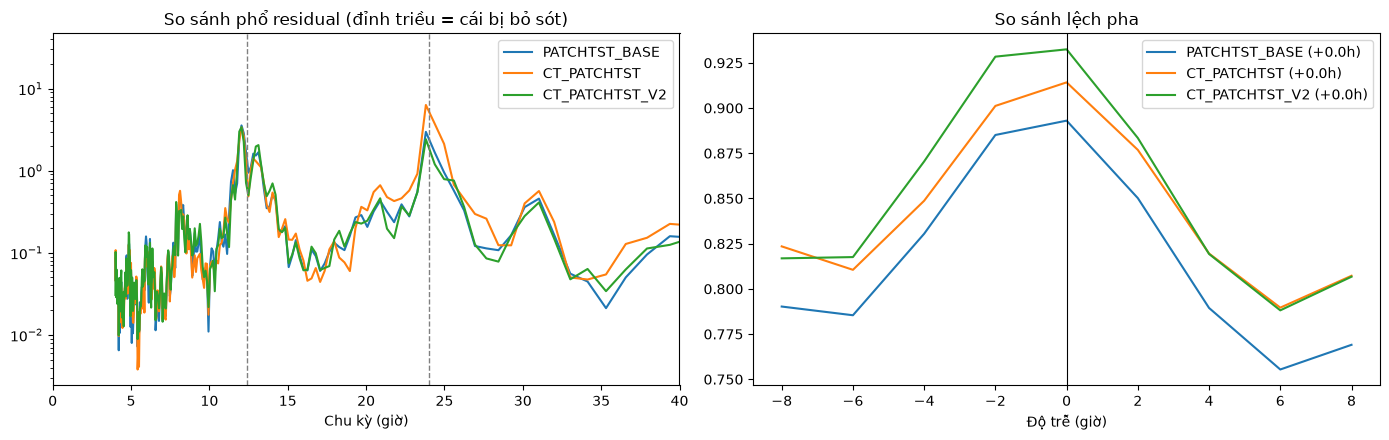

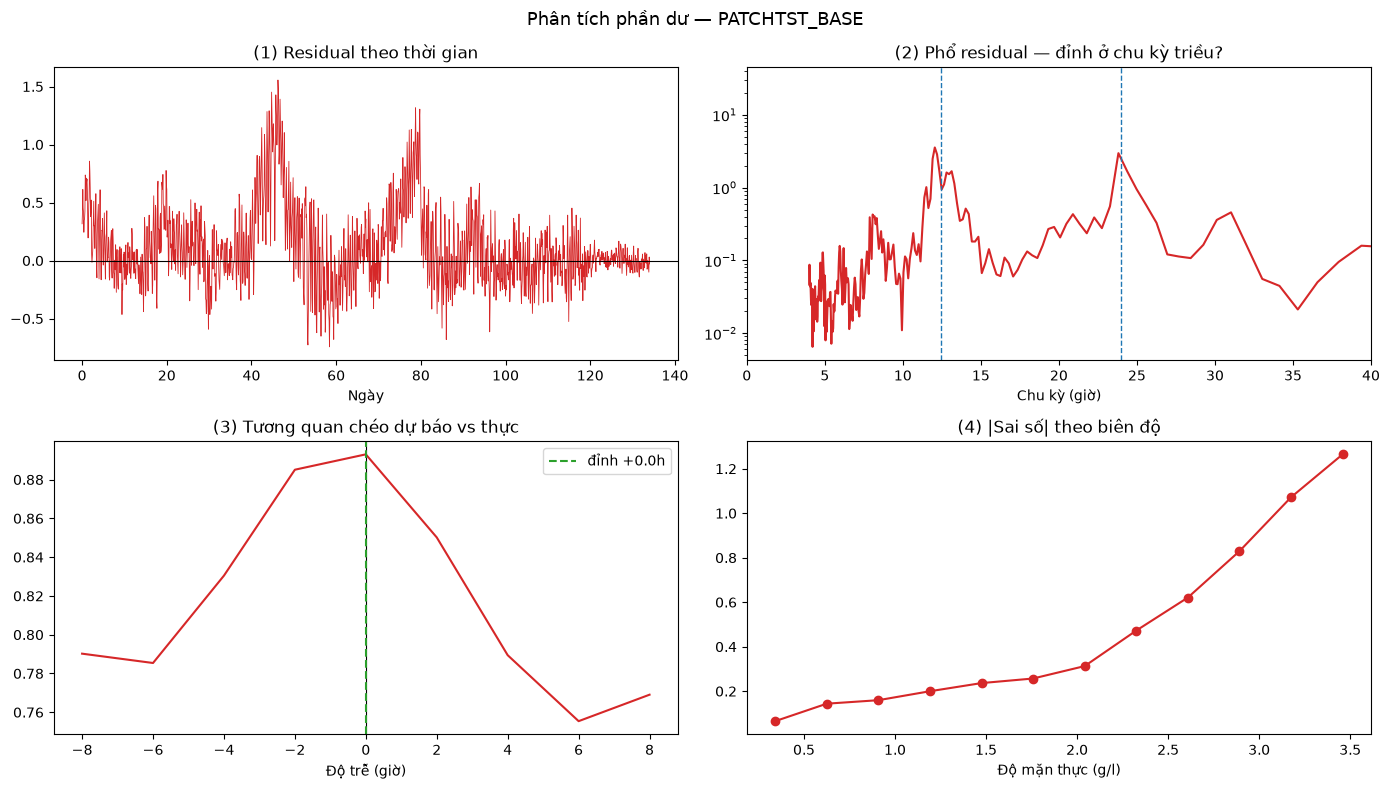

── PATCHTST_BASE ──
  RMSE=0.3554  MAE=0.2505  bias=+0.1182
  std(pred)/std(true) = 0.785 (BỊ LÀM PHẲNG)
  Lệch pha = +0.0 h | Chu kỳ trội residual = 12.0 h (2.8% công suất)



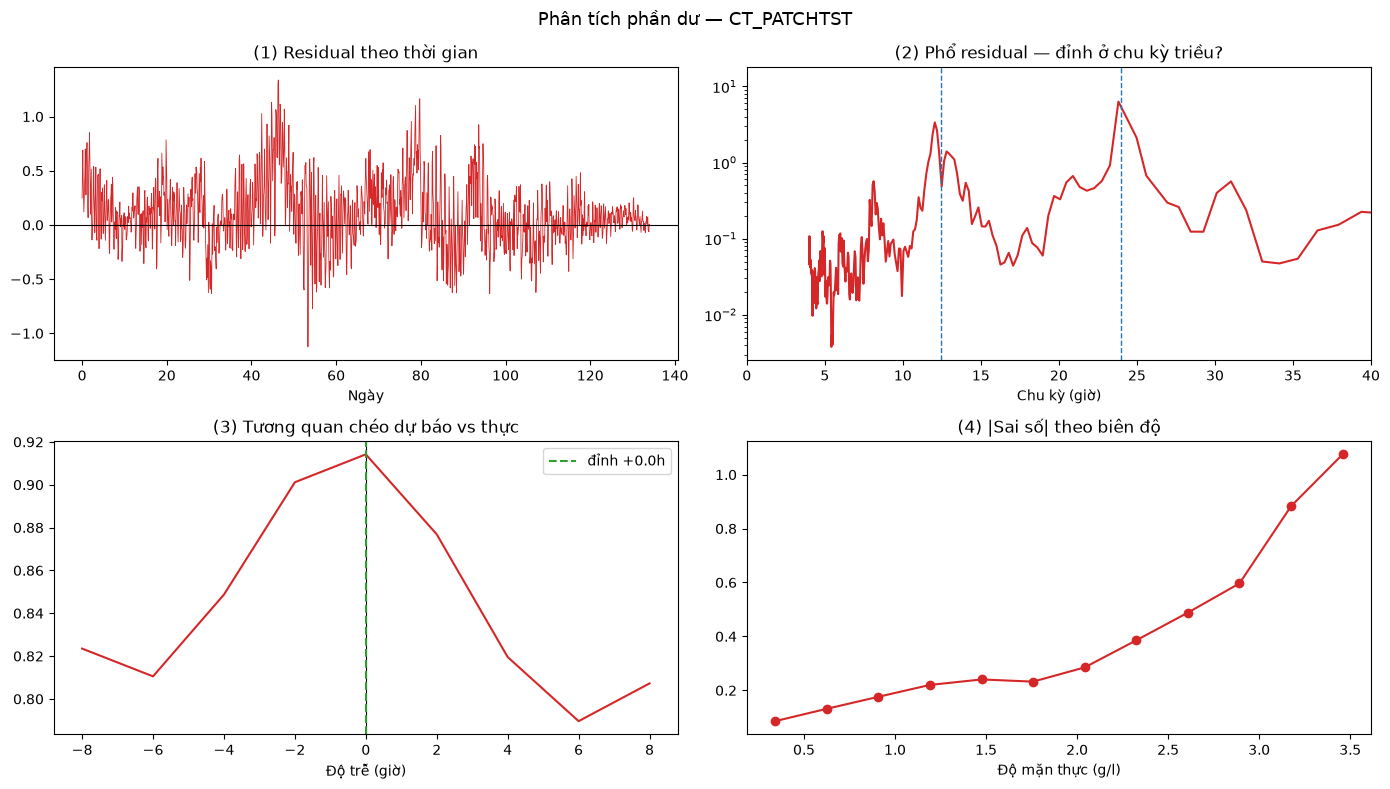

── CT_PATCHTST ──
  RMSE=0.3163  MAE=0.2346  bias=+0.1083
  std(pred)/std(true) = 0.850 (BỊ LÀM PHẲNG)
  Lệch pha = +0.0 h | Chu kỳ trội residual = 23.8 h (6.2% công suất)



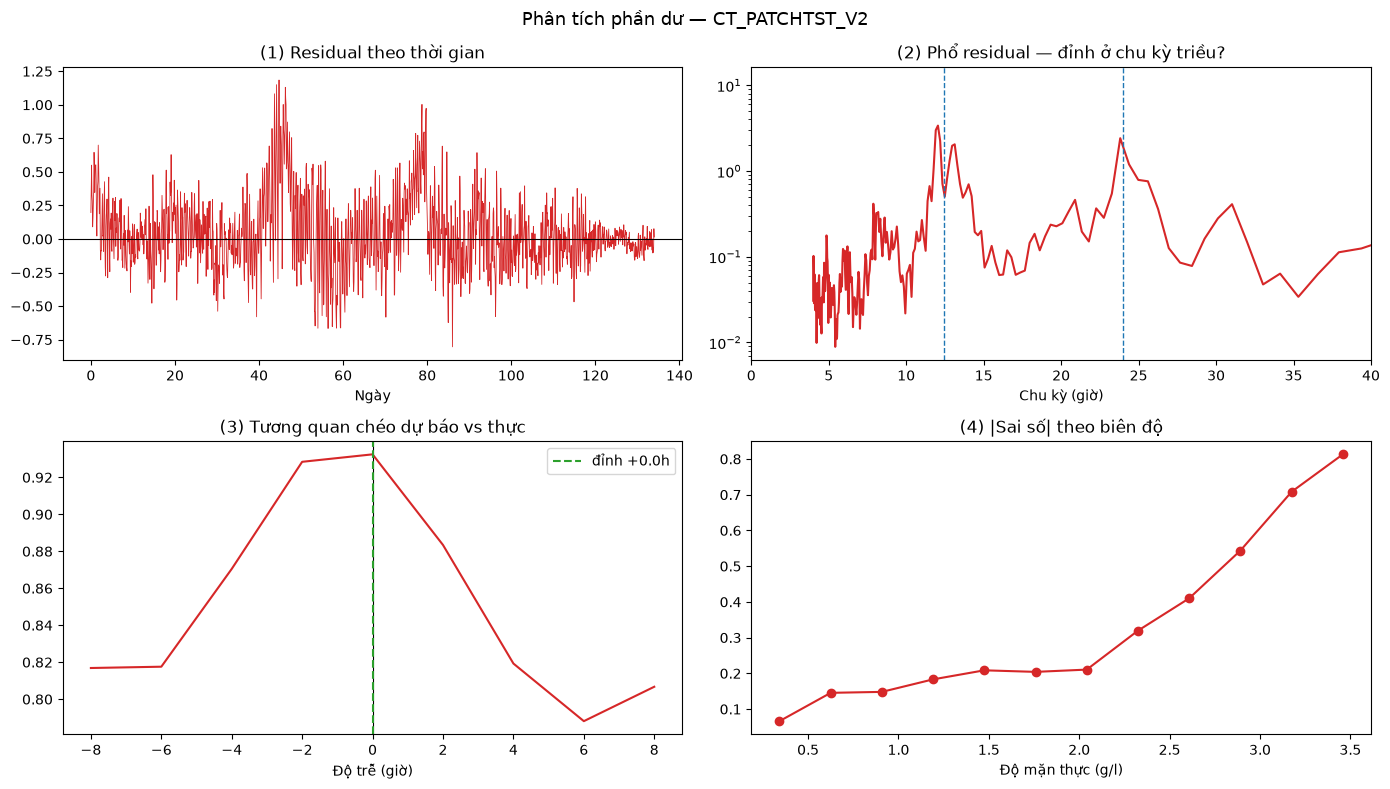

── CT_PATCHTST_V2 ──
  RMSE=0.2703  MAE=0.1994  bias=+0.0439
  std(pred)/std(true) = 0.861 (giữ tốt)
  Lệch pha = +0.0 h | Chu kỳ trội residual = 12.0 h (4.0% công suất)



In [19]:
# ===== Chạy phân tích trên dự báo test đã lưu (RUN_STORE) =====
# LƯU Ý: phải chạy lại cell thí nghiệm (vòng lặp run_experiment) SAU khi đã thêm
# hook, để RUN_STORE được nạp. RUN_STORE[model] = {"preds","trues"} dạng (N, horizon).

assert "RUN_STORE" in globals() and len(RUN_STORE) > 0, (
    "RUN_STORE rỗng — hãy chạy lại cell vòng lặp run_experiment trước.")

LEAD = 0     # lead 0 = dự báo 2h tới (chuỗi sạch nhất); đổi 0..horizon-1 để soi lead xa

print(f"Các model có dự báo: {list(RUN_STORE)}\n" + "="*60)

# Hình quan trọng nhất: phổ residual & lệch pha của tất cả model chồng nhau
compare_spectra(RUN_STORE, lead=LEAD)

# Chi tiết 4 phép cho từng model + bảng chỉ số
metrics = {}
for name, d in RUN_STORE.items():
    yt, yp = continuous_series(d["preds"], d["trues"], lead=LEAD)
    metrics[name] = analyze_model(yt, yp, name=name)
